# Time-Varying Parameter (TVP) Forecaster

This notebook demonstrates the **Time-Varying Parameter (TVP)** forecaster in the `aeon` toolkit. TVP is a linear autoregression — like the AR part of [ARIMA](arima.ipynb) — but with a crucial twist: its coefficients are **not fixed**. They are re-estimated at every time step by a **Kalman filter**, so the model can adapt as the behaviour of the series changes.

This makes TVP a natural choice for series with **structural change** — a shifting level, a changing trend, or evolving dynamics — where a fixed-coefficient model would be stuck with a compromise fit. It can be viewed as an online regression whose learning rate (the Kalman gain) is set automatically from the estimated parameter uncertainty, rather than fixed as in stochastic gradient descent.

> J. Durbin & S. J. Koopman (2012). *Time Series Analysis by State Space Methods* (2nd ed.), Oxford University Press.


## 1. How the TVP algorithm works

TVP fits a linear autoregression on the last `window` values, with an intercept:

$$\hat{y}_t = \beta_{0,t} + \beta_{1,t}\,y_{t-1} + \dots + \beta_{k,t}\,y_{t-k}.$$

The difference from ordinary AR regression is the subscript $t$ on the coefficients: each $\beta$ **evolves over time**. TVP treats the coefficient vector as a hidden state in a state-space model and updates it with the **Kalman filter**. At each step $t$:

1. **Predict**: the coefficient covariance grows by the state-noise term ($P \leftarrow P + Q$, where $Q = $ `beta_var` $\cdot I$), reflecting that the coefficients may have drifted.
2. **Observe**: form the forecast error $\varepsilon_t = y_t - x_t^\top \beta$ and its variance $s = x_t^\top P x_t + $ `var`.
3. **Update**: compute the **Kalman gain** $K = P x_t / s$ and correct the coefficients, $\beta \leftarrow \beta + K\,\varepsilon_t$, then shrink the covariance.

The Kalman gain $K$ plays the role of a *per-step, per-coefficient learning rate*. Where the model is uncertain (large $P$) it adapts quickly; where it is confident it barely moves. The two variances control the balance:

- **`var`** (observation noise): how noisy each observation is assumed to be. *Small* `var` &rarr; trust recent observations &rarr; fast adaptation. *Large* `var` &rarr; treat moves as noise &rarr; slow adaptation.
- **`beta_var`** (state-evolution noise): how fast the coefficients are allowed to drift. *Small* &rarr; nearly constant coefficients; *large* &rarr; freely moving coefficients.


## 2. Parameters and their effects

- **`window`** (required): number of autoregressive lags (named `window` to match `RegressionForecaster`). The model has `window + 1` coefficients (lags plus an intercept).
- **`horizon`** (default `1`): the step ahead the model is trained to predict.
- **`var`** (default `0.01`): observation-noise variance — the recency / adaptation-speed knob described above.
- **`beta_var`** (default `0.01`): state-evolution variance — how quickly the coefficients may change.

After fitting, the final coefficient vector is available as `_beta` (length `window + 1`, intercept first). TVP supports both **iterative** (recursive) and **direct** multi-step forecasting via `iterative_forecast` and `direct_forecast`.


## 3. Forecasting with TVP

### Imports


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.forecasting import RegressionForecaster
from aeon.forecasting.stats import TVP

### Example: fit, `forecast` and `iterative_forecast`

We use the same trending series as the [ARIMA](arima.ipynb) / [ETS](ets.ipynb) notebooks and hold out the last 12 points. TVP fits an autoregression on `window` lags; here `window=3`.


One-step-ahead forecast: 33.234
fitted coefficients _beta: [0.2186 0.6174 0.1761 0.215 ]


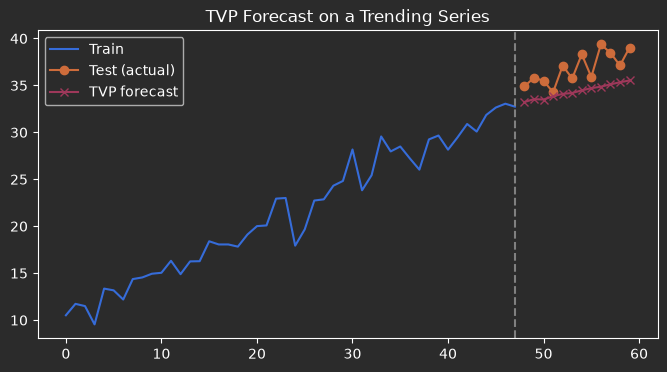

Test MSE over 12 steps: 7.225


In [3]:
# A trending series + noise (same as the ARIMA / ETS / CES notebooks)
rng = np.random.default_rng(1)
n_points = 60
time = np.arange(n_points)
y = 10 + 0.5 * time + rng.normal(scale=1.5, size=n_points)

y_train, y_test = y[:-12], y[-12:]

forecaster = TVP(window=3)
forecaster.fit(y_train)
print(f"One-step-ahead forecast: {forecaster.forecast(y_train):.3f}")
print(f"fitted coefficients _beta: {np.round(forecaster._beta, 4)}")

y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=len(y_test))

test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="TVP forecast")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("TVP Forecast on a Trending Series")
plt.show()

print(f"Test MSE over {len(y_test)} steps: " f"{np.mean((y_test - y_preds) ** 2):.3f}")

On a plain linear trend TVP behaves much like an ordinary AR model — its real advantage shows up when the dynamics *change* (section 5).


## 4. Worked example: the Kalman filter update

The whole of TVP's fit is the Kalman recursion in section 1. We can reimplement it in a few lines and confirm it reproduces the library's fitted coefficients exactly. The function below also records the one-step **fitted values** and the **intercept path**, which we reuse in the next section.


In [4]:
def tvp_filter(series, window, var, beta_var, horizon=1):
    """Run the TVP Kalman filter; return final beta, fitted values, beta path."""
    X = np.lib.stride_tricks.sliding_window_view(series, window_shape=window)
    X = X[:-horizon]
    X = np.hstack([np.ones((X.shape[0], 1)), X])  # intercept column
    y_train = series[window + horizon - 1 :]

    k = X.shape[1]
    beta = np.zeros(k)
    P = np.eye(k)
    Q = beta_var * np.eye(k)

    fitted, beta_path = [], []
    for t in range(len(y_train)):
        x_t = X[t]
        P = P + Q  # 1. predict covariance
        fitted.append(x_t @ beta)  # one-step fitted value
        error = y_train[t] - x_t @ beta  # 2. observe
        s = x_t @ P @ x_t + var
        K = P @ x_t / s  # Kalman gain
        beta = beta + K * error  # 3. update
        P = P - np.outer(K, x_t) @ P
        beta_path.append(beta.copy())
    return beta, np.array(fitted), np.array(beta_path)


beta_manual, _, _ = tvp_filter(y_train, window=3, var=0.01, beta_var=0.01)
print("manual _beta :", np.round(beta_manual, 6))
print("library _beta:", np.round(forecaster._beta, 6))
print("max abs diff :", np.max(np.abs(beta_manual - forecaster._beta)))

manual _beta : [0.218571 0.617442 0.176118 0.214995]
library _beta: [0.218571 0.617442 0.176118 0.214995]
max abs diff : 0.0


## 5. Where TVP does well: changing dynamics

TVP's advantage appears when the behaviour of the series changes over time. We look at two facets: how it *adapts* internally (a level shift), and how that translates into *better forecasts* through a regime change (a trend reversal).

### Adapting to a level shift

Consider a series whose **level jumps** half-way through. A fixed-coefficient model has to compromise across both regimes, but TVP can re-estimate its coefficients and lock onto the new level. The `var` parameter controls how fast it does so.


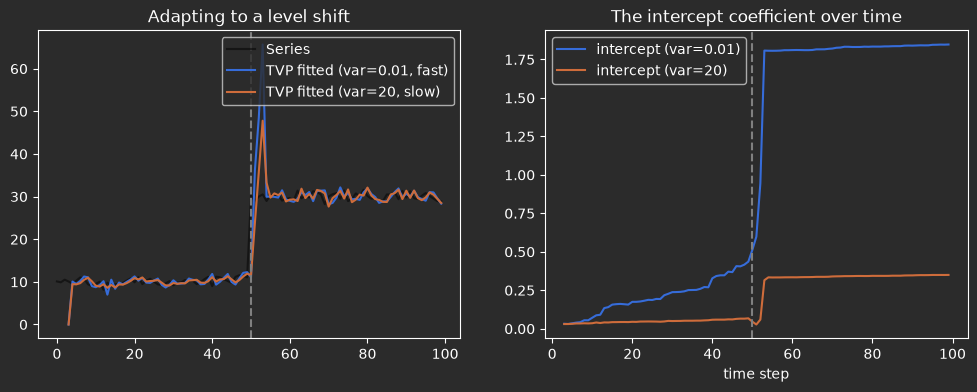

In [5]:
# Flat around 10, then a jump to around 30
rng = np.random.default_rng(0)
y_break = np.concatenate(
    [
        10 + rng.normal(scale=0.8, size=50),
        30 + rng.normal(scale=0.8, size=50),
    ]
)

# Same model, two observation-noise settings: fast vs slow adaptation
_, fitted_fast, path_fast = tvp_filter(y_break, window=3, var=0.01, beta_var=0.01)
_, fitted_slow, path_slow = tvp_filter(y_break, window=3, var=20.0, beta_var=0.01)
offset = 3  # fitted values start after the first `window` points
idx = np.arange(offset, offset + len(fitted_fast))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(y_break, color="black", alpha=0.5, label="Series")
ax1.plot(idx, fitted_fast, label="TVP fitted (var=0.01, fast)")
ax1.plot(idx, fitted_slow, label="TVP fitted (var=20, slow)")
ax1.axvline(50, linestyle="--", color="grey")
ax1.set_title("Adapting to a level shift")
ax1.legend()

ax2.plot(idx, path_fast[:, 0], label="intercept (var=0.01)")
ax2.plot(idx, path_slow[:, 0], label="intercept (var=20)")
ax2.axvline(50, linestyle="--", color="grey")
ax2.set_title("The intercept coefficient over time")
ax2.set_xlabel("time step")
ax2.legend()
plt.show()

The left panel shows the fast model (small `var`) snapping to the new level within a few steps, while the slow model (large `var`) drifts up only gradually. The right panel makes the "time-varying parameter" literal: the intercept coefficient is *not constant* — it climbs from roughly the old level to the new one. That adaptivity is the whole point of TVP, and it is exactly what a fixed-coefficient AR model cannot do.


### Forecasting through a trend reversal

Now a forecasting test. The series below trends **up** and then **down**; we fit once on the whole history (which spans the reversal) and forecast the continuing downward regime. A fixed-coefficient regression (`RegressionForecaster`, ordinary least squares on the same window) weights every point equally, so it averages the up- and down-phases and mis-projects the future. TVP's Kalman-updated coefficients are dominated by the *recent* downward dynamics, so it extrapolates the right direction.


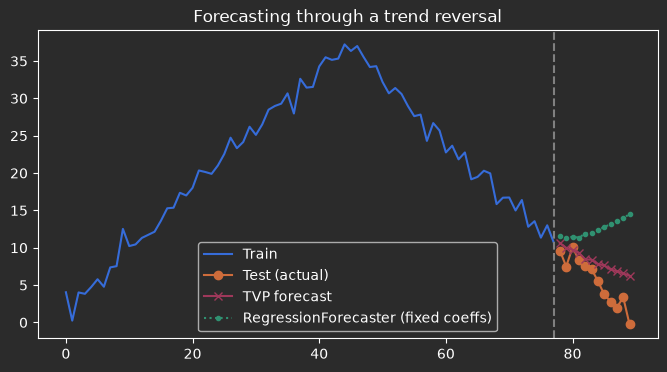

TVP test MSE        : 10.47
Regression test MSE : 64.23


In [6]:
# A trend that reverses; the held-out test continues the downward regime
rng = np.random.default_rng(3)
up = 2 + 0.8 * np.arange(45)
down = up[-1] - 0.8 * np.arange(1, 46)
y_rev = np.concatenate([up, down]) + rng.normal(scale=1.0, size=90)
y_train, y_test = y_rev[:-12], y_rev[-12:]

tvp_preds = TVP(window=5, var=0.01).iterative_forecast(y_train, 12)
reg_preds = RegressionForecaster(window=5).iterative_forecast(y_train, 12)

test_time = np.arange(len(y_train), len(y_rev))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, tvp_preds, marker="x", label="TVP forecast")
plt.plot(
    test_time,
    reg_preds,
    marker=".",
    linestyle=":",
    label="RegressionForecaster (fixed coeffs)",
)
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("Forecasting through a trend reversal")
plt.show()

print(f"TVP test MSE        : {np.mean((y_test - tvp_preds) ** 2):.2f}")
print(f"Regression test MSE : {np.mean((y_test - reg_preds) ** 2):.2f}")

TVP makes much smaller errors here: it follows the recent downward trend, while the fixed regression splits the difference between the two phases and forecasts an almost flat continuation. This is the same lesson as the level-shift example — when the dynamics move, letting the coefficients move with them pays off.


## 6. How TVP relates to the other forecasters

TVP sits in the autoregressive corner of the family, next to [ARIMA](arima.ipynb):

| Method | Form | Coefficients |
|---|---|---|
| `RegressionForecaster` | AR regression on a window | fixed (OLS) |
| **[ARIMA](arima.ipynb)** | AR + differencing + MA of errors | fixed (MLE) |
| **TVP** | AR regression on a window | **time-varying (Kalman)** |

All three predict from recent values, but only TVP lets the coefficients move. This is a different kind of adaptivity from the smoothing family: [ETS](ets.ipynb) and [CES](ces.ipynb) adapt a *level/state* while keeping their smoothing parameters fixed, whereas TVP adapts the *regression coefficients themselves*. When a series is stationary with stable dynamics, the fixed-coefficient models are usually preferable (fewer things to drift); when the dynamics change over time, TVP's moving coefficients earn their keep.


## 7. Summary

- **TVP** is a windowed autoregression whose coefficients are updated every step by a **Kalman filter**, so the model adapts to changing dynamics.
- The **Kalman gain** acts as an automatic per-coefficient learning rate; **`var`** sets the adaptation speed (small = fast) and **`beta_var`** sets how freely the coefficients may drift.
- The entire fit is the short Kalman recursion reproduced in section 4.
- TVP excels on series with **structural change** (level shifts, regime changes), where it beats fixed-coefficient AR models like `RegressionForecaster` and [ARIMA](arima.ipynb).

### Reference

J. Durbin & S. J. Koopman (2012). *Time Series Analysis by State Space Methods* (2nd ed.), Oxford University Press.
